In [ ]:
# DataLab 12-B2 - Cálculo do Valor em Risco de Ativos em uma Carteira
# Autora: Gabriela Alvim De Nigris
# Data: 01/06/2026

In [1]:
# import das bibliotecas
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
import matplotlib.pyplot as plt

In [ ]:
# coletar os dados históricos
ativos_selecionados = {'AAPL', 'KO'} #ticker da carteira

# faz o donwload dos ativos
df_ativos = yf.download(ativos_selecionados, start='2025-01-01', end='2026-01-01')['Close']
df_ativos

# calculo dos retornos diários
retornos = df_ativos.pct_change().dropna()
retornos
len(retornos)

# definir pesos da carteira
pesos_ativos_carteira = np.array([0.4, 0.6])

# cálculo dos retornos da carteira de investimento
retorno_carteira = retornos.dot(pesos_ativos_carteira) # produto cartesiano
retorno_carteira

In [12]:
# Cálculo do VaR (Value at Risk)
valor_portifolio = 500000 # (500 mil reais)
intervalo_confianca = 0.95
alpha = 1 - intervalo_confianca

# cálculo do VaR Histórico
VaR_historico_percentil = np.percentile(retorno_carteira, (alpha * 100))
VaR_historico = valor_portifolio * abs(VaR_historico_percentil)

# cálculo do VaR Paramétrico
media = retorno_carteira.mean()
volatilidade = retorno_carteira.std()
z = norm.ppf(alpha)

VaR_parametrico = valor_portifolio * abs(media + z * volatilidade)

# observar os resultados
print(f"VaR Histórico (95%): R$ {VaR_historico:.2f}")
print(f"VaR Paramétrico (95%): R$ {VaR_parametrico:.2f}")


VaR Histórico (95%): R$ 7489.78
VaR Paramétrico (95%): R$ 8768.12


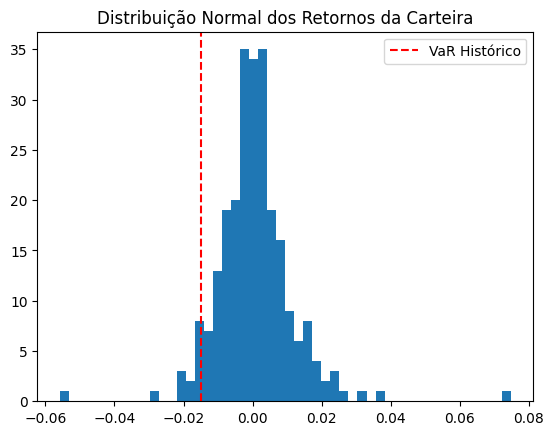

In [13]:
# criar a visulização da normal para o VaR calculado
plt.hist(retorno_carteira, bins=50)
plt.axvline(VaR_historico_percentil, color='r', linestyle='dashed', label='VaR Histórico')
plt.title('Distribuição Normal dos Retornos da Carteira')
plt.legend()
plt.show()